# 📊 Análise Exploratória dos Dados

Este notebook tem como objetivo realizar uma análise exploratória da base de dados de transações de clientes, com foco em:

- Entendimento das variáveis
- Identificação de problemas nos dados
- Análise de distribuição
- Identificação de padrões relevantes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
from pathlib import Path

project_root = Path.cwd().parent
data_path = project_root / "data" / "raw" / "customer_segmentation.xlsx"

df = pd.read_excel(data_path)

print("Shape:", df.shape)
df.head()

Shape: (75000, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
1,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
2,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
3,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
4,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    75000 non-null  object        
 1   StockCode    75000 non-null  object        
 2   Description  74792 non-null  str           
 3   Quantity     75000 non-null  int64         
 4   InvoiceDate  75000 non-null  datetime64[us]
 5   UnitPrice    75000 non-null  float64       
 6   CustomerID   56167 non-null  float64       
 7   Country      75000 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(2)
memory usage: 4.6+ MB


In [4]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,75000.000000,75000,75000.000000,56167.000000
mean,9.374267,2011-07-04 08:40:01.288800,4.753187,15280.997899
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,1.000000,2011-03-28 12:23:00,1.250000,13949.000000
50%,3.000000,2011-07-19 12:19:00,2.080000,15128.000000
75%,10.000000,2011-10-18 16:58:00,4.130000,16794.000000
max,74215.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,403.739881,NaN,89.101606,1716.916450


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

CustomerID     18833
Description      208
dtype: int64

In [6]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

CustomerID     25.110667
Description     0.277333
dtype: float64

In [7]:
print("Clientes únicos:", df["CustomerID"].nunique())
print("Transações:", df["InvoiceNo"].nunique())

Clientes únicos: 3983
Transações: 16533


In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
df["InvoiceDate"].describe()

count                         75000
mean     2011-07-04 08:40:01.288800
min             2010-12-01 08:26:00
25%             2011-03-28 12:23:00
50%             2011-07-19 12:19:00
75%             2011-10-18 16:58:00
max             2011-12-09 12:50:00
Name: InvoiceDate, dtype: object

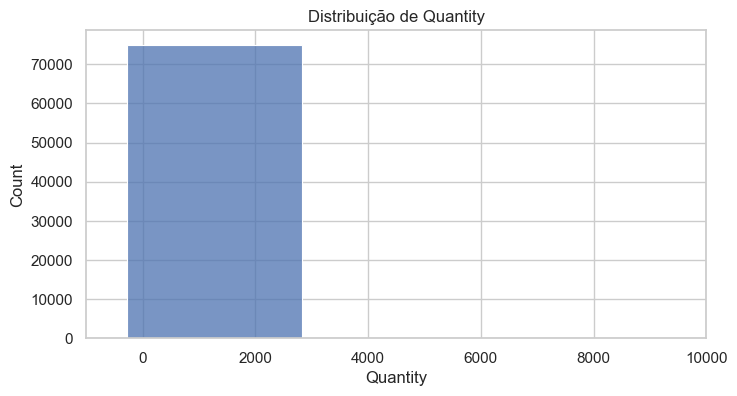

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df["Quantity"], bins=50)

plt.xlim(-1000, 10000)

plt.title("Distribuição de Quantity")
plt.show()